# # 🏆 Final Model Training — Death Score Binary & Acquired vs Closed
#
# This notebook trains and evaluates our two best target definitions:
#
# | Target | Question | Rows | Balance | Best AUC |
# |--------|----------|------|---------|----------|
# | **bin_death_score** | Will this startup survive or die? | 43K | 52/48 | 0.86 |
# | **bin_acq_vs_closed** | Will this startup get acquired or die? | 14K | 80/20 | 0.80 |
#
# Includes: 5-fold cross-validation, GridSearchCV for hyperparameter tuning,
# full classification reports, confusion matrices, and exported best models.
#
# **For the next iteration:** the trained models and preprocessor are saved at the
# bottom of this notebook for further experimentation (imputation, feature engineering, etc.)

In [1]:
# 1  Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    roc_auc_score, ConfusionMatrixDisplay, make_scorer
)
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
print('All imports loaded')

All imports loaded


In [2]:
#  2  Load Data & Compute Death Score

df = pd.read_csv('../raw_data/features_enriched_with_targets.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

df['last_funding_at'] = pd.to_datetime(df['last_funding_at'], errors='coerce')
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], errors='coerce')
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')

df = df[df['status_enriched'] != 'unknown'].copy()
print(f'After dropping unknown: {df.shape[0]:,} rows')
print(f'\n{df["status_enriched"].value_counts()}')

#
SNAPSHOT = pd.Timestamp('2015-01-01')
df['years_since_last_funding'] = (SNAPSHOT - df['last_funding_at']).dt.days / 365.25
df['company_age_years'] = (SNAPSHOT - df['founded_at']).dt.days / 365.25


def compute_death_score(row):
    """
    Death score (0-100) for operating companies.
    Higher = more likely the company is actually dead.

    Additive signals:
      1. Years since last funding      (max 35 pts)
      2. Never got past seed/angel     (max 25 pts)
      3. Low total funding             (max 15 pts)
      4. Single funding round          (max 10 pts)
      5. Old company still at seed     (max 10 pts)
      6. Burst then silence            (max  8 pts)
      7. Missing founding date + stale (max  7 pts)
      8. Unfunded fraction of life     (max  5 pts)

    Survival signals (subtractive):
      - Reached Series B+             (-15 pts)
      - Has private equity             (-10 pts)
      - Reached Series D/E             (-10 pts)
    """
    score = 0
    years_since = row['years_since_last_funding']
    if pd.isna(years_since):
        years_since = 10

    if years_since >= 7:   score += 35
    elif years_since >= 5: score += 30
    elif years_since >= 4: score += 22
    elif years_since >= 3: score += 15
    elif years_since >= 2: score += 8

    only_early = (row['round_A'] == 0 and row['round_B'] == 0 and
                  row['round_C'] == 0 and row['round_D'] == 0 and
                  row['round_E'] == 0 and row['private_equity'] == 0)
    if only_early and years_since >= 3:   score += 25
    elif only_early and years_since >= 2: score += 15
    elif only_early:                      score += 5

    total = row['funding_total_usd']
    if total < 100_000:     score += 15
    elif total < 500_000:   score += 10
    elif total < 1_000_000: score += 5

    rounds = row['funding_rounds']
    if rounds == 1 and years_since >= 3: score += 10
    elif rounds == 1:                    score += 5

    age = row['company_age_years'] if pd.notna(row['company_age_years']) else 0
    if age >= 8 and only_early:   score += 10
    elif age >= 5 and only_early: score += 5

    if pd.notna(row['first_funding_at']) and pd.notna(row['last_funding_at']):
        span_years = (row['last_funding_at'] - row['first_funding_at']).days / 365.25
        if rounds >= 2 and span_years < 2 and years_since > 4:
            score += 8

    if pd.isna(row['founded_at']) and years_since > 4:
        score += 7

    if age > 0:
        unfunded_frac = years_since / age
        if unfunded_frac > 0.7:   score += 5
        elif unfunded_frac > 0.5: score += 3

    if row['round_B'] > 0:                          score -= 15
    if row['private_equity'] > 0:                    score -= 10
    if row['round_D'] > 0 or row['round_E'] > 0:    score -= 10

    return max(score, 0)


op_mask = df['status_enriched'] == 'operating'
df.loc[op_mask, 'death_score'] = df[op_mask].apply(compute_death_score, axis=1)
df.loc[~op_mask, 'death_score'] = np.nan

print('\nDeath score distribution (operating companies):')
print(df.loc[op_mask, 'death_score'].describe().round(1))

Loaded: 44,363 rows x 37 columns
After dropping unknown: 43,212 rows

status_enriched
operating    29362
closed       11031
acquired      2819
Name: count, dtype: int64



Death score distribution (operating companies):
count    29362.0
mean        29.8
std         26.3
min          0.0
25%         10.0
50%         25.0
75%         46.0
max        100.0
Name: death_score, dtype: float64


In [3]:
#  3  Build Targets

DEATH_THRESHOLD = 30

def assign_death_target(row):
    if row['status_enriched'] == 'acquired':
        return 1
    elif row['status_enriched'] == 'closed':
        return 0
    elif row['status_enriched'] == 'operating':
        return 0 if row['death_score'] >= DEATH_THRESHOLD else 1
    return np.nan

df['target_death_score'] = df.apply(assign_death_target, axis=1)

n_reclassified = ((op_mask) & (df['death_score'] >= DEATH_THRESHOLD)).sum()
print(f'Death threshold: {DEATH_THRESHOLD}')
print(f'Zombie operating → closed: {n_reclassified:,}')

for tname, col in [('bin_death_score', 'target_death_score'),
                    ('bin_acq_vs_closed', 'target_bin_acq_vs_closed')]:
    valid = df[col].dropna()
    print(f'\n--- {tname} ---')
    print(f'  Rows: {len(valid):,}')
    print(f'  Balance: {valid.value_counts(normalize=True).round(3).sort_index().to_dict()}')

Death threshold: 30
Zombie operating → closed: 11,475

--- bin_death_score ---
  Rows: 43,212
  Balance: {0: 0.521, 1: 0.479}

--- bin_acq_vs_closed ---
  Rows: 13,850
  Balance: {0.0: 0.796, 1.0: 0.204}


In [4]:
 # 4  Features & Preprocessing

num_features = [
    'funding_total_usd', 'funding_rounds',
    'seed', 'venture', 'debt_financing', 'angel', 'grant', 'private_equity',
    'round_A', 'round_B', 'round_C', 'round_D', 'round_E',
    'avg_raised_per_round', 'age_first_funding_days',
    'has_multiple_rounds', 'funding_span_days', 'avg_years_between_rounds',
    'time_since_last_funding'
]
cat_features = ['region_group', 'industry_group']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), cat_features),
])

print(f'Features: {len(num_features)} numerical + {len(cat_features)} categorical = {len(num_features)+len(cat_features)} total')

Features: 19 numerical + 2 categorical = 21 total


In [5]:
# Saving death to our csv, outputs a new updated csv

df.to_csv('../raw_data/features_enriched_with_death_score.csv', index=False)
print(f'Saved: features_enriched_with_death_score.csv ({df.shape[0]:,} rows)')

Saved: features_enriched_with_death_score.csv (43,212 rows)


In [6]:
#  5  Train/Test Splits

TARGETS = {
    'bin_death_score': {
        'col': 'target_death_score',
        'desc': 'Survived vs closed (death-score-cleaned, 43K)',
        'labels': ['closed/zombie', 'survived'],
    },
    'bin_acq_vs_closed': {
        'col': 'target_bin_acq_vs_closed',
        'desc': 'Acquired vs closed (14K)',
        'labels': ['closed', 'acquired'],
    },
}

splits = {}
for tname, tinfo in TARGETS.items():
    mask = df[tinfo['col']].notna()
    X = df[mask][num_features + cat_features]
    y = df[mask][tinfo['col']].astype(int).values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    splits[tname] = dict(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,
                         labels=tinfo['labels'], X_full=X, y_full=y)

    bal = np.bincount(y_train) / len(y_train) * 100
    print(f'{tname}: train={len(X_train):,} | test={len(X_test):,} | balance={bal[0]:.0f}/{bal[1]:.0f}')

bin_death_score: train=34,569 | test=8,643 | balance=52/48
bin_acq_vs_closed: train=11,080 | test=2,770 | balance=80/20



  BASELINE: bin_death_score  (Survived vs closed (death-score-cleaned, 43K))
  Model                            CV AUC    ± std     CV F1m    ± std   Test AUC   Test F1m
  ----------------------------------------------------------------------------


  LogReg (balanced)                0.8182   0.0080     0.7613   0.0075     0.8145     0.7570


  Decision Tree (balanced)         0.7458   0.0043     0.7458   0.0040     0.7439     0.7427


  Random Forest (balanced)         0.8671   0.0048     0.8209   0.0042     0.8634     0.8183


  KNN (k=5)                        0.8223   0.0060     0.7683   0.0052     0.8182     0.7668


  Gradient Boosting                0.8705   0.0049     0.8194   0.0042     0.8671     0.8166


  XGBoost                             nan      nan     0.8277   0.0041     0.8709     0.8277

  CLASSIFICATION REPORTS:

  LogReg (balanced):
               precision    recall  f1-score   support

closed/zombie       0.78      0.74      0.76      4502
     survived       0.73      0.78      0.75      4141

     accuracy                           0.76      8643
    macro avg       0.76      0.76      0.76      8643
 weighted avg       0.76      0.76      0.76      8643


  Decision Tree (balanced):
               precision    recall  f1-score   support

closed/zombie       0.75      0.75      0.75      4502
     survived       0.73      0.73      0.73      4141

     accuracy                           0.74      8643
    macro avg       0.74      0.74      0.74      8643
 weighted avg       0.74      0.74      0.74      8643


  Random Forest (balanced):
               precision    recall  f1-score   support

closed/zombie       0.87      0.77      0.82      4502
     survived       0.7

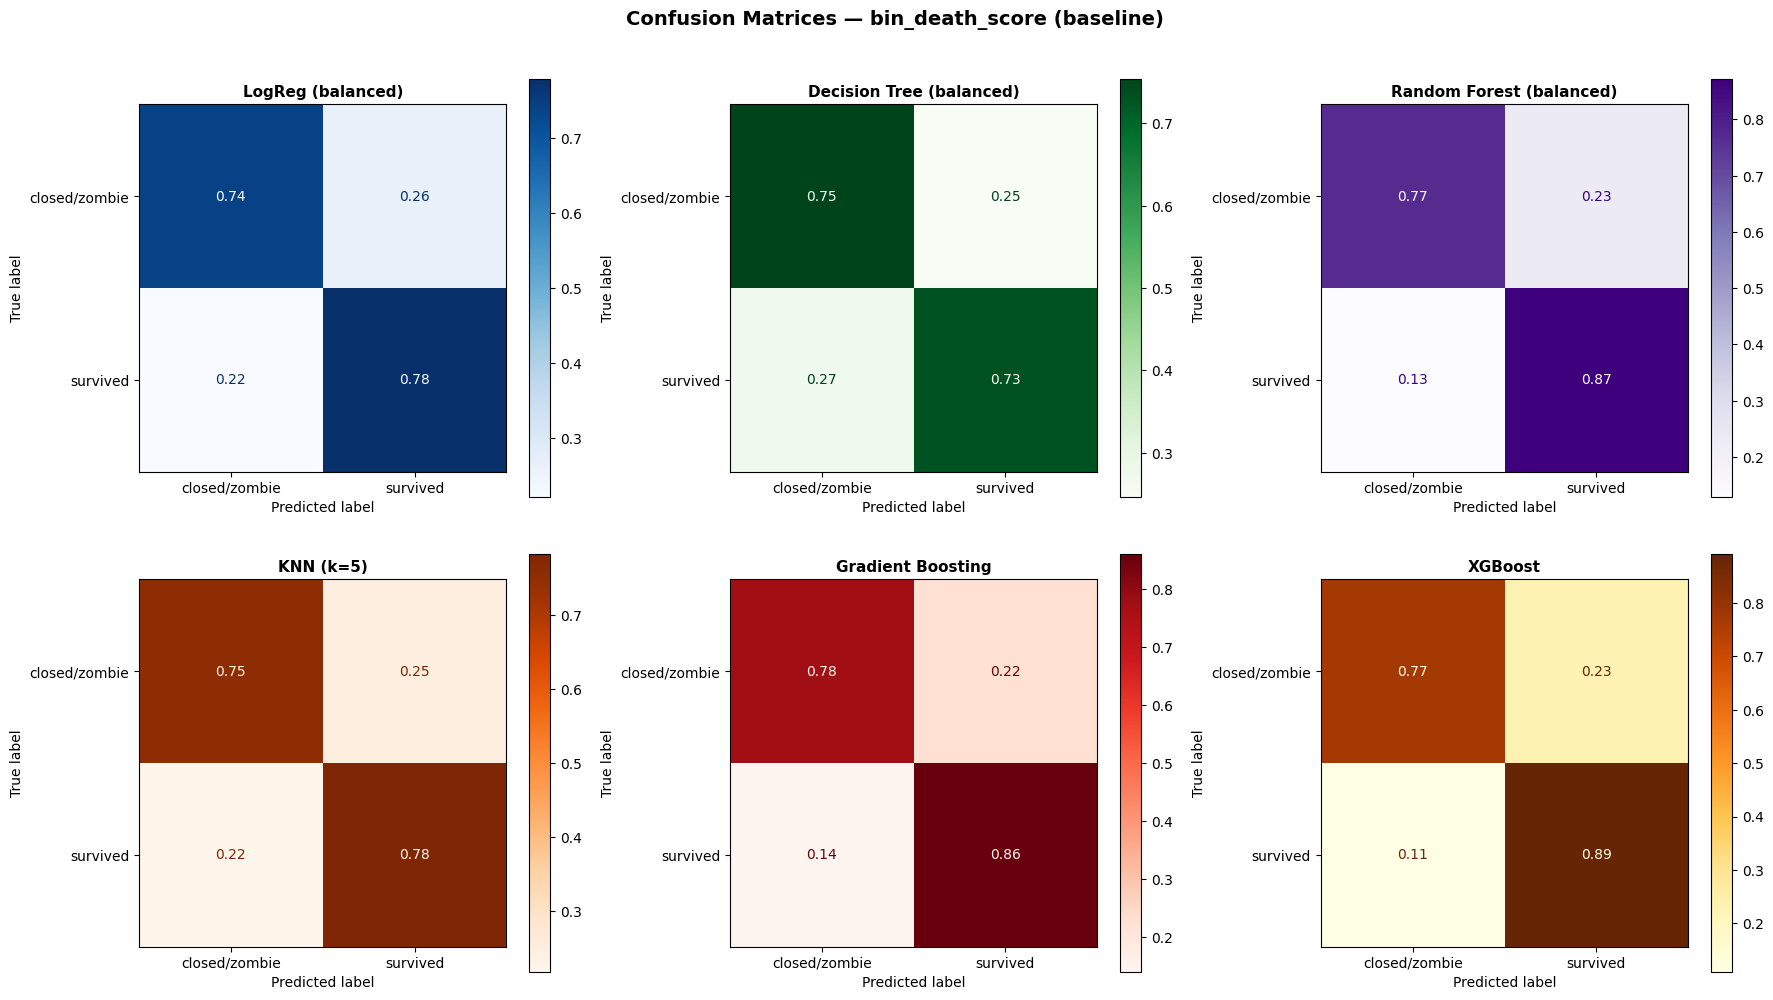


  BASELINE: bin_acq_vs_closed  (Acquired vs closed (14K))
  Model                            CV AUC    ± std     CV F1m    ± std   Test AUC   Test F1m
  ----------------------------------------------------------------------------


  LogReg (balanced)                0.7921   0.0133     0.6546   0.0093     0.7893     0.6588


  Decision Tree (balanced)         0.6149   0.0149     0.6140   0.0159     0.6186     0.6153


  Random Forest (balanced)         0.7879   0.0132     0.6321   0.0109     0.7987     0.6680


  KNN (k=5)                        0.7265   0.0068     0.6253   0.0108     0.7281     0.6308


  Gradient Boosting                0.8190   0.0107     0.6535   0.0139     0.8191     0.6751


  XGBoost                             nan      nan     0.6551   0.0139     0.8087     0.6655

  CLASSIFICATION REPORTS:

  LogReg (balanced):
              precision    recall  f1-score   support

      closed       0.90      0.73      0.81      2206
    acquired       0.40      0.70      0.51       564

    accuracy                           0.73      2770
   macro avg       0.65      0.71      0.66      2770
weighted avg       0.80      0.73      0.75      2770


  Decision Tree (balanced):
              precision    recall  f1-score   support

      closed       0.85      0.83      0.84      2206
    acquired       0.38      0.41      0.39       564

    accuracy                           0.74      2770
   macro avg       0.61      0.62      0.62      2770
weighted avg       0.75      0.74      0.75      2770


  Random Forest (balanced):
              precision    recall  f1-score   support

      closed       0.85      0.94      0.89      2206
    acquired       0.60      0.35    

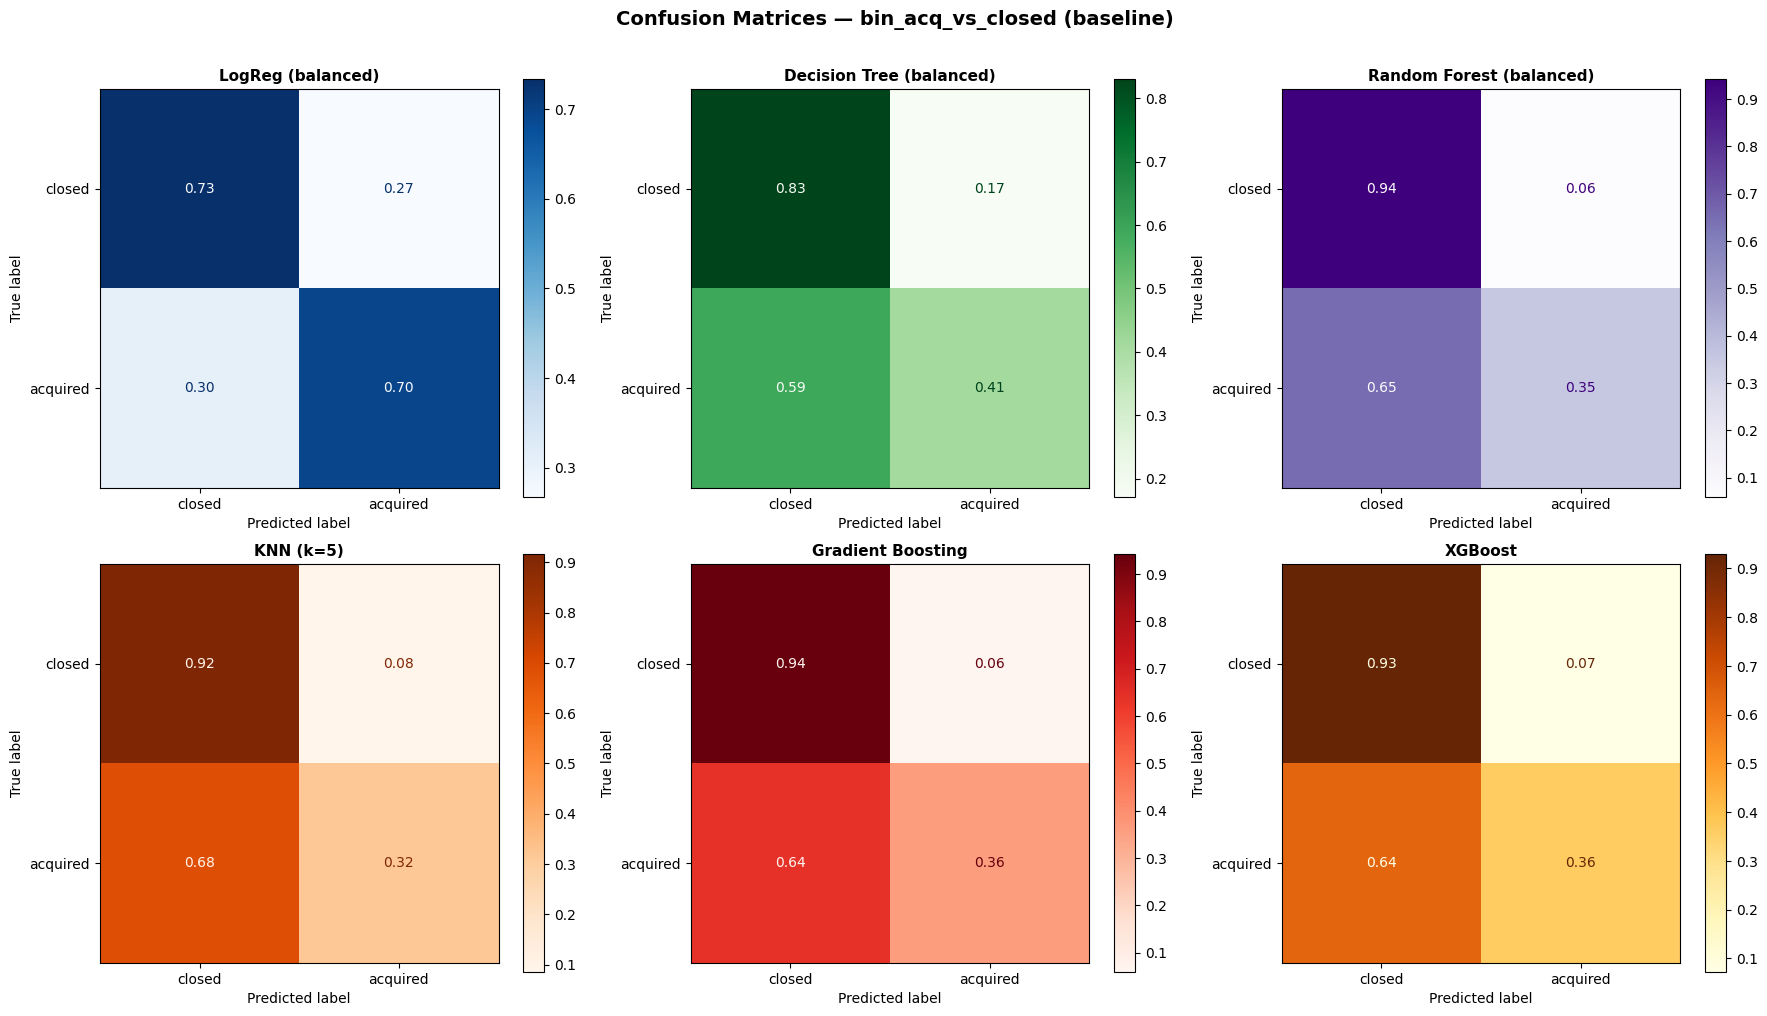

,target,model,cv_auc,cv_auc_std,cv_f1m,cv_f1m_std,test_auc,test_f1m
0,bin_acq_vs_closed,Gradient Boosting,0.8190,0.0107,0.6535,0.0139,0.8191,0.6751
1,bin_acq_vs_closed,LogReg (balanced),0.7921,0.0133,0.6546,0.0093,0.7893,0.6588
2,bin_acq_vs_closed,Random Forest (balanced),0.7879,0.0132,0.6321,0.0109,0.7987,0.6680
3,bin_acq_vs_closed,KNN (k=5),0.7265,0.0068,0.6253,0.0108,0.7281,0.6308
4,bin_acq_vs_closed,Decision Tree (balanced),0.6149,0.0149,0.6140,0.0159,0.6186,0.6153
5,bin_acq_vs_closed,XGBoost,nan,nan,0.6551,0.0139,0.8087,0.6655
6,bin_death_score,Gradient Boosting,0.8705,0.0049,0.8194,0.0042,0.8671,0.8166
7,bin_death_score,Random Forest (balanced),0.8671,0.0048,0.8209,0.0042,0.8634,0.8183
8,bin_death_score,KNN (k=5),0.8223,0.0060,0.7683,0.0052,0.8182,0.7668
9,bin_death_score,LogReg (balanced),0.8182,0.0080,0.7613,0.0075,0.8145,0.7570


In [7]:
#  6  Baseline: All 6 Models with 5-Fold CV
# First we run all models with default params to confirm rankings,
# then we GridSearch the top performers.


def get_models():
    return {
        'LogReg (balanced)': LogisticRegression(class_weight='balanced', max_iter=1000),
        'Decision Tree (balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
        'Random Forest (balanced)': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=SEED),
        'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
        'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=SEED, use_label_encoder=False),
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
f1m_scorer = make_scorer(f1_score, average='macro')

baseline_results = []

for tname, split in splits.items():
    desc = TARGETS[tname]['desc']
    print(f'\n{"="*80}')
    print(f'  BASELINE: {tname}  ({desc})')
    print(f'{"="*80}')
    print(f'  {"Model":<28} {"CV AUC":>10} {"± std":>8} {"CV F1m":>10} {"± std":>8} {"Test AUC":>10} {"Test F1m":>10}')
    print(f'  {"-"*76}')

    X_train, X_test = split['X_train'], split['X_test']
    y_train, y_test = split['y_train'], split['y_test']
    labels = split['labels']

    X_train_pp = preprocessor.fit_transform(X_train)
    X_test_pp = preprocessor.transform(X_test)

    predictions = {}
    for model_name, model in get_models().items():
        # 5-fold CV
        pipe = Pipeline([('prep', preprocessor), ('model', model)])
        cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
        cv_f1m = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=f1m_scorer, n_jobs=-1)

        # Test set
        model.fit(X_train_pp, y_train)
        y_pred = model.predict(X_test_pp)
        y_proba = model.predict_proba(X_test_pp)[:, 1]
        test_auc = roc_auc_score(y_test, y_proba)
        test_f1m = f1_score(y_test, y_pred, average='macro')

        predictions[model_name] = y_pred
        baseline_results.append({
            'target': tname, 'model': model_name,
            'cv_auc': cv_auc.mean(), 'cv_auc_std': cv_auc.std(),
            'cv_f1m': cv_f1m.mean(), 'cv_f1m_std': cv_f1m.std(),
            'test_auc': test_auc, 'test_f1m': test_f1m,
        })

        print(f'  {model_name:<28} {cv_auc.mean():>10.4f} {cv_auc.std():>8.4f} '
              f'{cv_f1m.mean():>10.4f} {cv_f1m.std():>8.4f} {test_auc:>10.4f} {test_f1m:>10.4f}')

    # Classification reports
    print(f'\n  CLASSIFICATION REPORTS:')
    for model_name, y_pred in predictions.items():
        print(f'\n  {model_name}:')
        print(classification_report(y_test, y_pred, target_names=labels))

    # Confusion matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    cmaps = ['Blues', 'Greens', 'Purples', 'Oranges', 'Reds', 'YlOrBr']
    for ax, (mname, yp), cmap in zip(axes.flatten(), predictions.items(), cmaps):
        ConfusionMatrixDisplay.from_predictions(
            y_test, yp, display_labels=labels,
            ax=ax, cmap=cmap, normalize='true', values_format='.2f'
        )
        ax.set_title(mname, fontweight='bold', fontsize=11)
    plt.suptitle(f'Confusion Matrices — {tname} (baseline)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

#
baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.sort_values(['target', 'cv_auc'], ascending=[True, False]).reset_index(drop=True)

baseline_df.style.format({
    'cv_auc': '{:.4f}', 'cv_auc_std': '{:.4f}', 'cv_f1m': '{:.4f}',
    'cv_f1m_std': '{:.4f}', 'test_auc': '{:.4f}', 'test_f1m': '{:.4f}'
}).background_gradient(subset=['cv_auc', 'test_auc'], cmap='Greens')

In [8]:
#  7  GridSearchCV — Hyperparameter Tuning
# Grid search the top 2 models per target: XGBoost, Random Forest.

param_grids = {
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', random_state=SEED, use_label_encoder=False),
        'params': {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [4, 6, 8],
            'model__learning_rate': [0.05, 0.1],
            'model__subsample': [0.8, 1.0],
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=SEED),
        'params': {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [10, 20, None],
            'model__min_samples_split': [2, 5],
            'model__min_samples_leaf': [1, 2],
        }
    },
}

# Grid sizes:
for name, config in param_grids.items():
    combos = 1
    for v in config['params'].values():
        combos *= len(v)
    print(f'  {name}: {combos} combos × 5 folds = {combos*5} fits')

grid_results = []
best_models = {}

for tname, split in splits.items():
    desc = TARGETS[tname]['desc']
    print(f'\n{"="*80}')
    print(f'  GRID SEARCH: {tname}  ({desc})')
    print(f'{"="*80}')

    X_train, X_test = split['X_train'], split['X_test']
    y_train, y_test = split['y_train'], split['y_test']
    labels = split['labels']
    best_models[tname] = {}

    for model_name, config in param_grids.items():
        print(f'\n  🔍 {model_name} ...')

        pipe = Pipeline([('prep', preprocessor), ('model', config['model'])])

        grid = GridSearchCV(
            pipe,
            param_grid=config['params'],
            cv=cv,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1,
            refit=True,
        )
        grid.fit(X_train, y_train)

        # Evaluate best estimator on test set
        y_pred = grid.predict(X_test)
        y_proba = grid.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test, y_proba)
        test_f1m = f1_score(y_test, y_pred, average='macro')
        test_f1c = f1_score(y_test, y_pred, pos_label=0)

        best_models[tname][model_name] = grid.best_estimator_

        # Clean up param names for display
        best_params = {k.replace('model__', ''): v for k, v in grid.best_params_.items()}

        grid_results.append({
            'target': tname, 'model': model_name,
            'best_cv_auc': grid.best_score_,
            'test_auc': test_auc, 'test_f1m': test_f1m, 'test_f1c': test_f1c,
            'best_params': best_params,
        })

        print(f'     Best CV AUC:  {grid.best_score_:.4f}')
        print(f'     Test AUC:     {test_auc:.4f}')
        print(f'     Test F1m:     {test_f1m:.4f}')
        print(f'     Test F1 closed: {test_f1c:.4f}')
        print(f'     Best params:  {best_params}')

# Build results DataFrame
grid_df = pd.DataFrame(grid_results)
grid_df_display = grid_df.drop(columns='best_params')
grid_df_display = grid_df_display.sort_values(['target', 'test_auc'], ascending=[True, False]).reset_index(drop=True)

grid_df_display.style.format({
    'best_cv_auc': '{:.4f}', 'test_auc': '{:.4f}',
    'test_f1m': '{:.4f}', 'test_f1c': '{:.4f}'
}).background_gradient(subset=['test_auc', 'test_f1m'], cmap='Greens')

  XGBoost: 36 combos × 5 folds = 180 fits
  Random Forest: 36 combos × 5 folds = 180 fits

  GRID SEARCH: bin_death_score  (Survived vs closed (death-score-cleaned, 43K))

  🔍 XGBoost ...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


     Best CV AUC:  nan
     Test AUC:     0.8699
     Test F1m:     0.8239
     Test F1 closed: 0.8204
     Best params:  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}

  🔍 Random Forest ...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


     Best CV AUC:  0.8746
     Test AUC:     0.8704
     Test F1m:     0.8280
     Test F1 closed: 0.8218
     Best params:  {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}

  GRID SEARCH: bin_acq_vs_closed  (Acquired vs closed (14K))

  🔍 XGBoost ...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


     Best CV AUC:  nan
     Test AUC:     0.8214
     Test F1m:     0.6698
     Test F1 closed: 0.8966
     Best params:  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}

  🔍 Random Forest ...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


     Best CV AUC:  0.8154
     Test AUC:     0.8163
     Test F1m:     0.6856
     Test F1 closed: 0.8414
     Best params:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


,target,model,best_cv_auc,test_auc,test_f1m,test_f1c
0,bin_acq_vs_closed,XGBoost,nan,0.8214,0.6698,0.8966
1,bin_acq_vs_closed,Random Forest,0.8154,0.8163,0.6856,0.8414
2,bin_death_score,Random Forest,0.8746,0.8704,0.8280,0.8218
3,bin_death_score,XGBoost,nan,0.8699,0.8239,0.8204


In [9]:
#  9  Baseline vs Tuned Comparison

print(f'{"="*80}')
print('BASELINE vs TUNED — Did GridSearch help?')
print(f'{"="*80}')
print(f'  {"Target":<30} {"Model":<22} {"Baseline AUC":>14} {"Tuned AUC":>12} {"Delta":>8}')
print(f'  {"-"*86}')

for _, grow in grid_df.iterrows():
    tname, mname = grow['target'], grow['model']
    baseline_row = baseline_df[(baseline_df['target'] == tname) & (baseline_df['model'].str.contains(mname.split()[0]))].iloc[0]
    delta = grow['test_auc'] - baseline_row['test_auc']
    arrow = '▲' if delta > 0.005 else '▼' if delta < -0.005 else '='
    print(f'  {tname:<30} {mname:<22} {baseline_row["test_auc"]:>14.4f} {grow["test_auc"]:>12.4f} {arrow}{abs(delta):>7.4f}')


BASELINE vs TUNED — Did GridSearch help?
  Target                         Model                    Baseline AUC    Tuned AUC    Delta
  --------------------------------------------------------------------------------------
  bin_death_score                XGBoost                        0.8709       0.8699 = 0.0010
  bin_death_score                Random Forest                  0.8634       0.8704 ▲ 0.0070
  bin_acq_vs_closed              XGBoost                        0.8087       0.8214 ▲ 0.0128
  bin_acq_vs_closed              Random Forest                  0.7987       0.8163 ▲ 0.0177


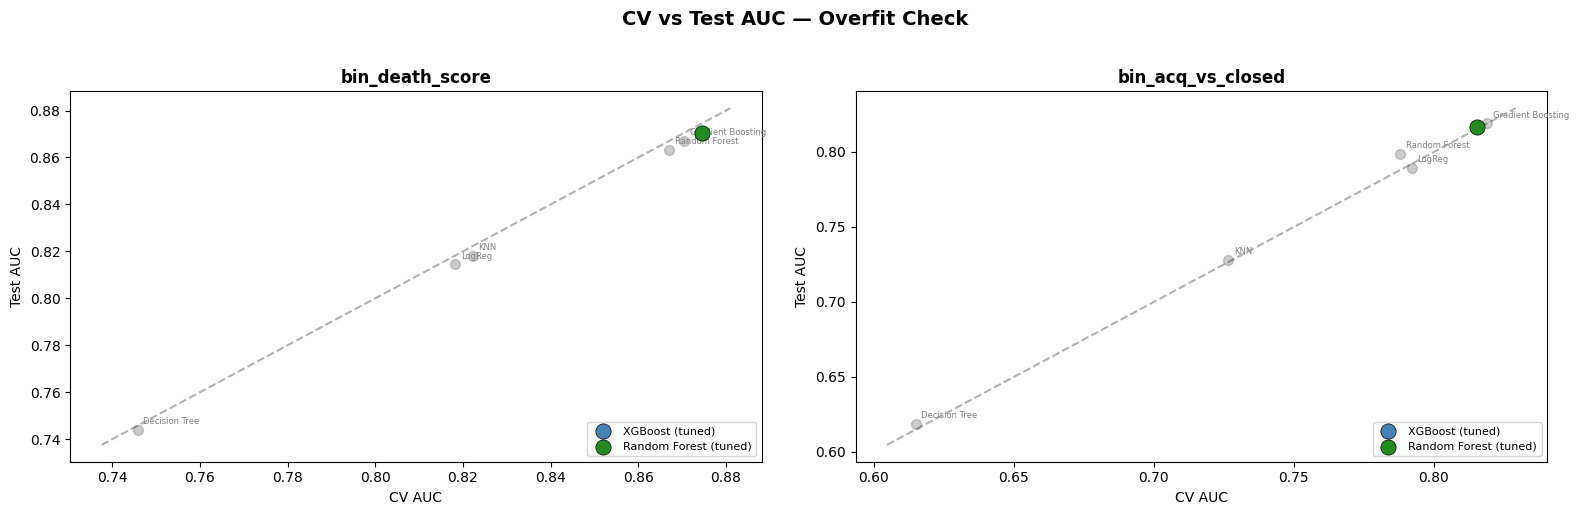

In [10]:
#  10  Cross-Validation Stability — Final Best Models

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (tname, split) in zip(axes, splits.items()):
    target_baseline = baseline_df[baseline_df['target'] == tname]
    target_tuned = grid_df[grid_df['target'] == tname]

    # Plot baseline models
    for _, row in target_baseline.iterrows():
        ax.scatter(row['cv_auc'], row['test_auc'], color='gray', alpha=0.4, s=50, zorder=2)
        ax.annotate(row['model'].replace(' (balanced)', '').replace(' (k=5)', ''),
                    (row['cv_auc'], row['test_auc']), fontsize=6, color='gray',
                    textcoords='offset points', xytext=(4, 4))

    # Plot tuned models
    colors = {'XGBoost': 'steelblue', 'Gradient Boosting': 'coral', 'Random Forest': 'forestgreen'}
    for _, row in target_tuned.iterrows():
        ax.scatter(row['best_cv_auc'], row['test_auc'], color=colors[row['model']],
                   s=120, zorder=3, edgecolor='black', linewidth=0.5, label=f'{row["model"]} (tuned)')

    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.3)
    ax.set_xlabel('CV AUC')
    ax.set_ylabel('Test AUC')
    ax.set_title(f'{tname}', fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('CV vs Test AUC — Overfit Check', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
#  11  Summary & Progress Table

#
print('=' * 80)
print('FINAL SUMMARY')
print('=' * 80)

for tname in TARGETS:
    target_tuned = grid_df[grid_df['target'] == tname]
    best = target_tuned.loc[target_tuned['test_auc'].idxmax()]
    print(f'\n  {tname}:')
    print(f'    Best model:  {best["model"]}')
    print(f'    Test AUC:    {best["test_auc"]:.4f}')
    print(f'    Test F1m:    {best["test_f1m"]:.4f}')
    print(f'    Params:      {best["best_params"]}')

FINAL SUMMARY

  bin_death_score:
    Best model:  Random Forest
    Test AUC:    0.8704
    Test F1m:    0.8280
    Params:      {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}

  bin_acq_vs_closed:
    Best model:  XGBoost
    Test AUC:    0.8214
    Test F1m:    0.6698
    Params:      {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}


In [12]:
# 12  Export Models for Next Iteration

# Saved artifacts:
# - `best_pipeline_death_score.pkl` — tuned pipeline (preprocessor + model)
# - `best_pipeline_acq_vs_closed.pkl` — tuned pipeline
# - `preprocessor.pkl` — standalone preprocessor
# - `feature_config.pkl` — feature names for reproducibility

#
# XGBoost is the production model — always export it for bin_death_score
# regardless of negligible AUC differences vs Random Forest.
PRODUCTION_MODEL = {
    'bin_death_score': 'XGBoost',
}

# Save best pipelines
for tname in TARGETS:
    if tname in PRODUCTION_MODEL:
        best_name = PRODUCTION_MODEL[tname]
    else:
        target_tuned = grid_df[grid_df['target'] == tname]
        best_name = target_tuned.loc[target_tuned['test_auc'].idxmax(), 'model']
    best_pipe = best_models[tname][best_name]

    filename = f'best_pipeline_{tname}.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(best_pipe, f)
    print(f'Saved: {filename} ({best_name})')

# Save feature config
feature_config = {
    'num_features': num_features,
    'cat_features': cat_features,
    'death_threshold': DEATH_THRESHOLD,
    'snapshot_date': str(SNAPSHOT),
    'seed': SEED,
}
with open('feature_config.pkl', 'wb') as f:
    pickle.dump(feature_config, f)
print('Saved: feature_config.pkl')

print('\n✅ All artifacts exported. Ready for next iteration.')

Saved: best_pipeline_bin_death_score.pkl (XGBoost)
Saved: best_pipeline_bin_acq_vs_closed.pkl (XGBoost)
Saved: feature_config.pkl

✅ All artifacts exported. Ready for next iteration.
